In [1]:
import os
from os.path import join
import numpy as np
from scipy.stats import pearsonr
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from GPR_MLIP.evaluation import load_us_metrics, adjust_size, plot_single_us_metric

RESULT_ROOT_PATH = join('..', 'results', 'uncertainty_sampling')

In [2]:
def plot_US_LCs(al_dirs_, x_ticks_, y_ticks_, metric_name_, n_init_, n_al_):

    n_molecules = len(al_dirs_)

    n_samples = range(n_init_, n_init_ + n_al_)
    
    fig, axes = plt.subplots(1, n_molecules, figsize=(5*n_molecules, 5))

    for i, name in enumerate(al_dirs_.keys()):
        metrics = load_us_metrics(al_dirs_[name], UNCERTAINTY_NAMES)
        metrics = adjust_size(metrics, n_al_)

        axes[i] = plot_single_us_metric(
            axes[i],
            n_samples,
            metrics[metric_name_],
            x_ticks_,
            y_ticks_[name],
        )

        axes[i].xaxis.set_tick_params(labelsize=16)
        axes[i].yaxis.set_tick_params(labelsize=16)
        
        axes[i].set_xlabel('Number of training samples', fontsize=18)
        
        axes[i].set_title(name, fontsize=20)

    
    axes[0].legend(fontsize=14)
    axes[0].set_ylabel('MAE in meV', fontsize=18);

In [3]:
UNCERTAINTY_NAMES = ['Absolute error', 'Bootstrap aggregation', 'Random', 'Two sets', 'GPR standard deviation']

# Coulomb

In [4]:
al_dirs_coulomb = {
    'rMD17 benzene': join(RESULT_ROOT_PATH, 'rmd17', 'benzene', 'GPR_coulomb_rbf', 'default'),
    'rMD17 aspirin': join(RESULT_ROOT_PATH, 'rmd17', 'aspirin', 'GPR_coulomb_rbf', 'default'),
    'WS22 SMA': join(RESULT_ROOT_PATH, 'ws22', 'ws22_sma', 'GPR_coulomb_rbf', 'default'),
    'WS22 O-HBDI': join(RESULT_ROOT_PATH, 'ws22', 'ws22_o-hbdi', 'GPR_coulomb_rbf', 'default'),
    'Porphyrin': join(RESULT_ROOT_PATH, 'dftb', 'porphyrin', 'GPR_coulomb_rbf', 'default')
}

n_init_coulomb = 200
n_al_coulomb = 5000

x_ticks_coulomb = [200, 500, 1000, 2000, 5000]

### MAE

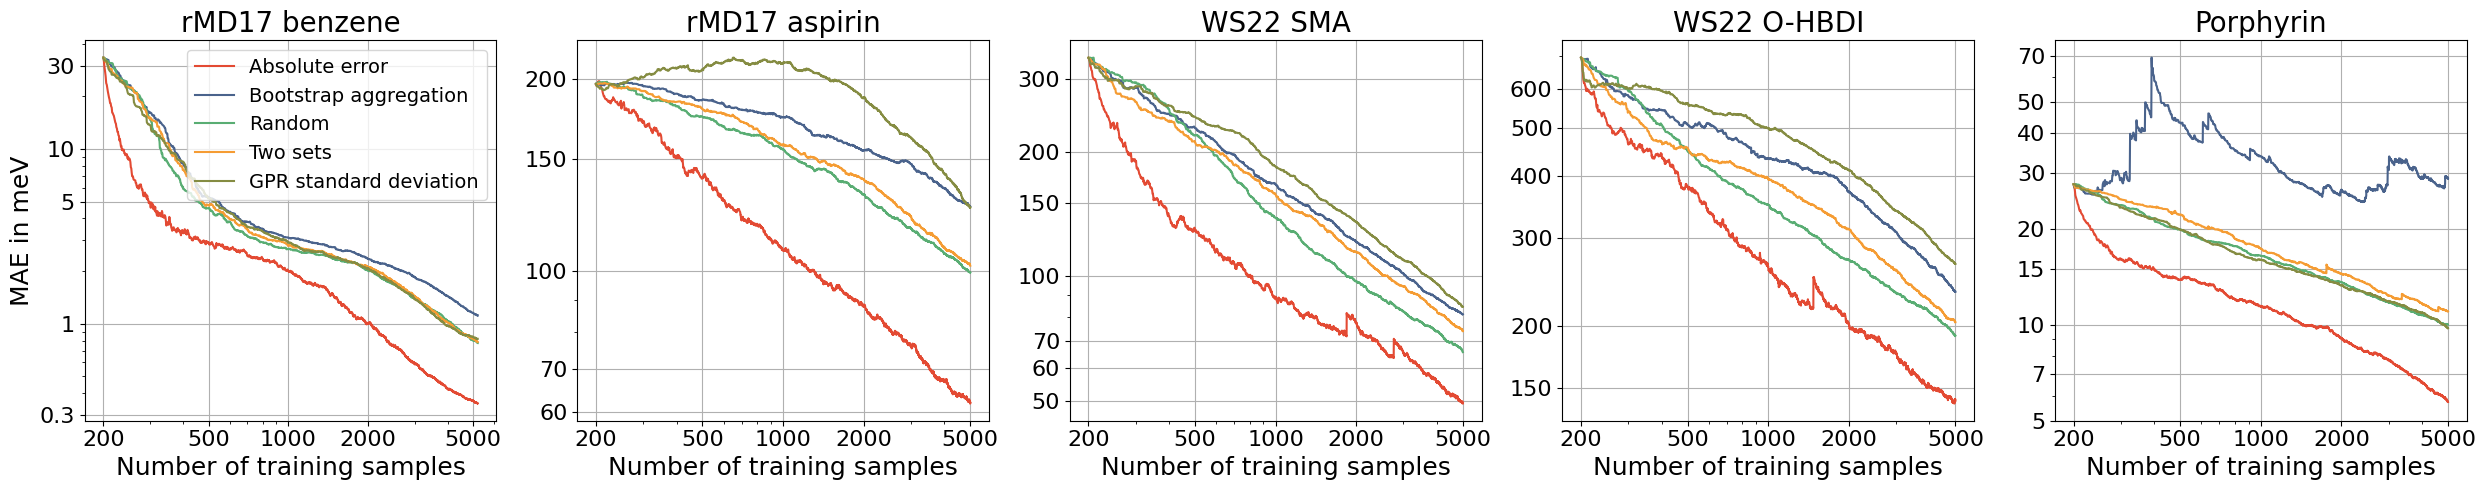

In [5]:
y_ticks = {
    'rMD17 benzene': [0.3, 1, 5, 10, 30],
    'rMD17 aspirin': [60, 70, 100, 150, 200],
    'WS22 SMA': [50, 60, 70, 100, 150, 200, 300],
    'WS22 O-HBDI': [150, 200, 300, 400, 500, 600],
    'Porphyrin': [5, 7, 10, 15, 20, 30, 40, 50, 70],
}

plot_US_LCs(al_dirs_coulomb, x_ticks_coulomb, y_ticks, 'MAE in meV', n_init_coulomb, n_al_coulomb)
plt.tight_layout()

### Max absolute error

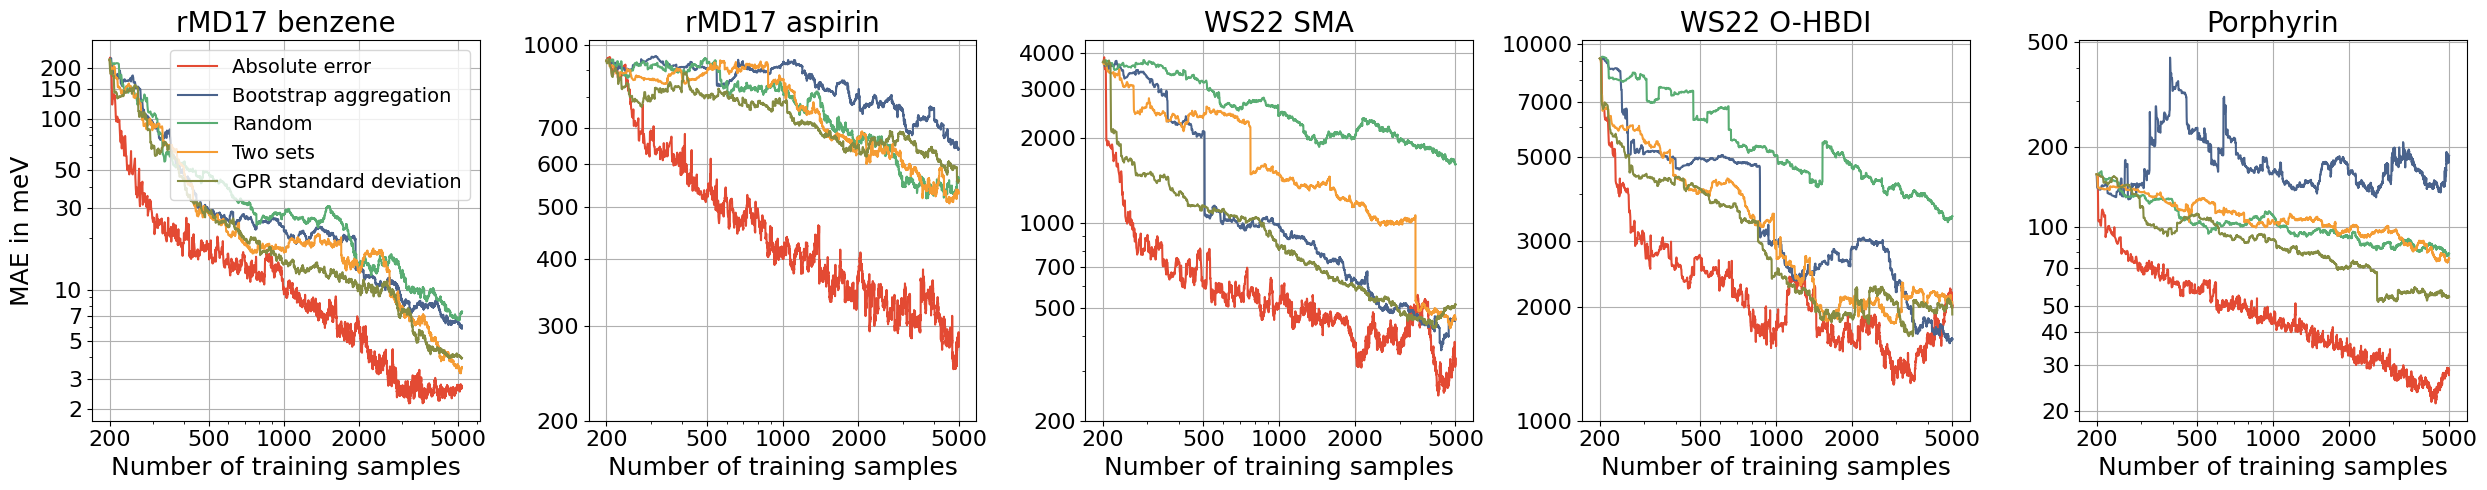

In [6]:
y_ticks = {
    'rMD17 benzene': [2, 3, 5, 7, 10, 30, 50, 100, 150, 200],
    'rMD17 aspirin': [200, 300, 400, 500, 600, 700, 1000],
    'WS22 SMA': [200, 500, 700, 1000, 2000, 3000, 4000],
    'WS22 O-HBDI': [1000, 2000, 3000, 5000, 7000, 10000],
    'Porphyrin': [20, 30, 40, 50, 70, 100, 200, 500],
}

plot_US_LCs(al_dirs_coulomb, x_ticks_coulomb, y_ticks, 'Max absolute error in meV', n_init_coulomb, n_al_coulomb)
plt.tight_layout()

### Test variance

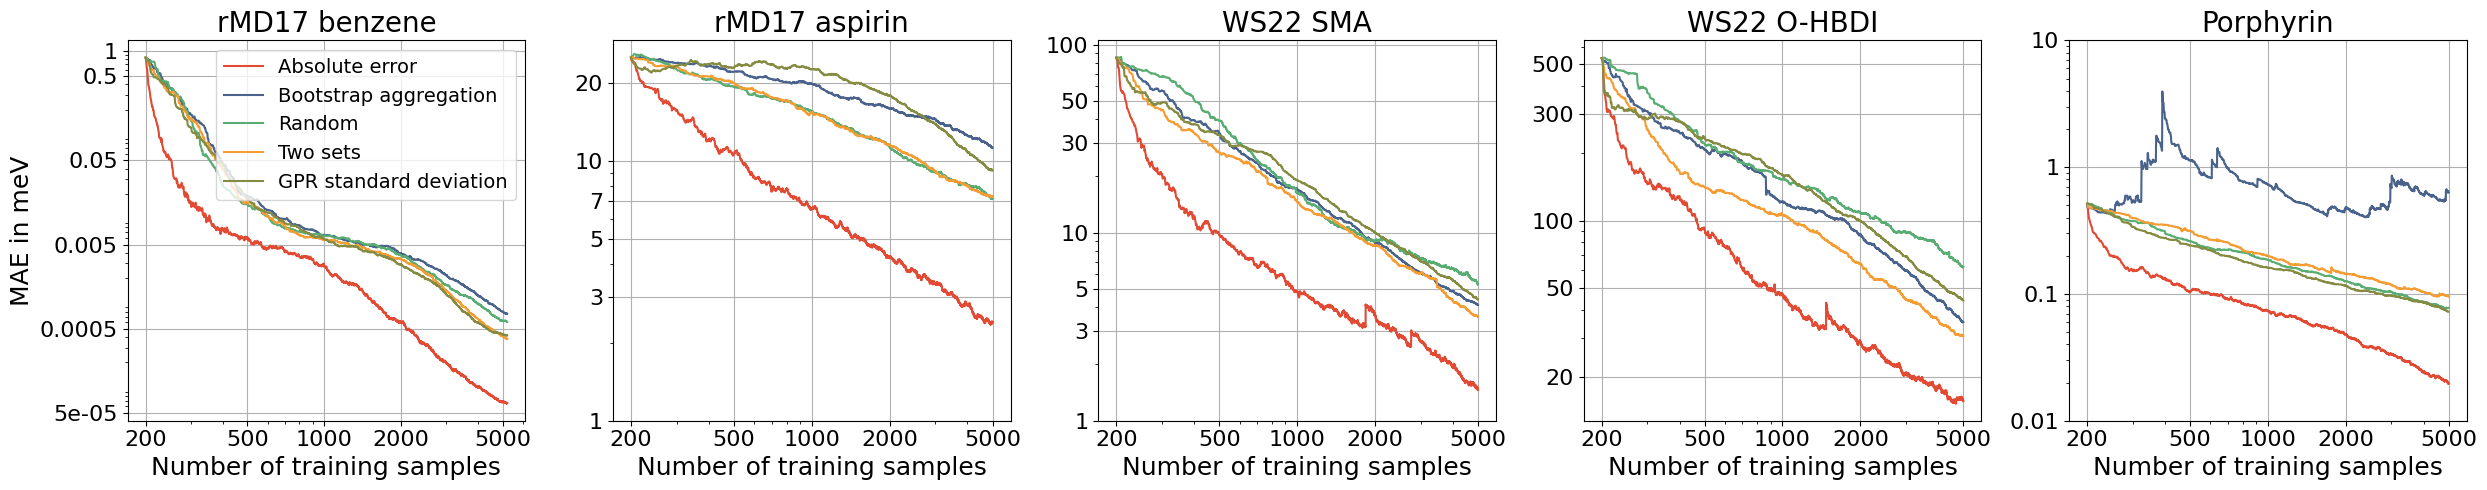

In [7]:
y_ticks = {
    'rMD17 benzene': [0.00005, 0.0005, 0.005, 0.05, 0.5, 1],
    'rMD17 aspirin': [1, 3, 5, 7, 10, 20],
    'WS22 SMA': [1, 3, 5, 10, 30, 50, 100],
    'WS22 O-HBDI': [20, 50, 100, 300, 500],
    'Porphyrin': [0.01, 0.1, 1, 10],
}

plot_US_LCs(al_dirs_coulomb, x_ticks_coulomb, y_ticks, 'Test variance in meV', n_init_coulomb, n_al_coulomb)
plt.tight_layout()

# SOAP

In [8]:
al_dirs_soap = {
    'rMD17 benzene': join(RESULT_ROOT_PATH, 'rmd17', 'benzene', 'GPR_soap_atomistic_atomistic_sum1', 'default'),
    'rMD17 aspirin': join(RESULT_ROOT_PATH, 'rmd17', 'aspirin', 'GPR_soap_atomistic_atomistic_sum1', 'default'),
    'WS22 SMA': join(RESULT_ROOT_PATH, 'ws22', 'ws22_sma', 'GPR_soap_atomistic_atomistic_sum1', 'default'),
    'WS22 O-HBDI': join(RESULT_ROOT_PATH, 'ws22', 'ws22_o-hbdi', 'GPR_soap_atomistic_atomistic_sum1', 'default'),
}

n_init_soap = 200
n_al_soap = 1200

x_ticks_soap = [200, 300, 400, 600, 1200]

### MAE

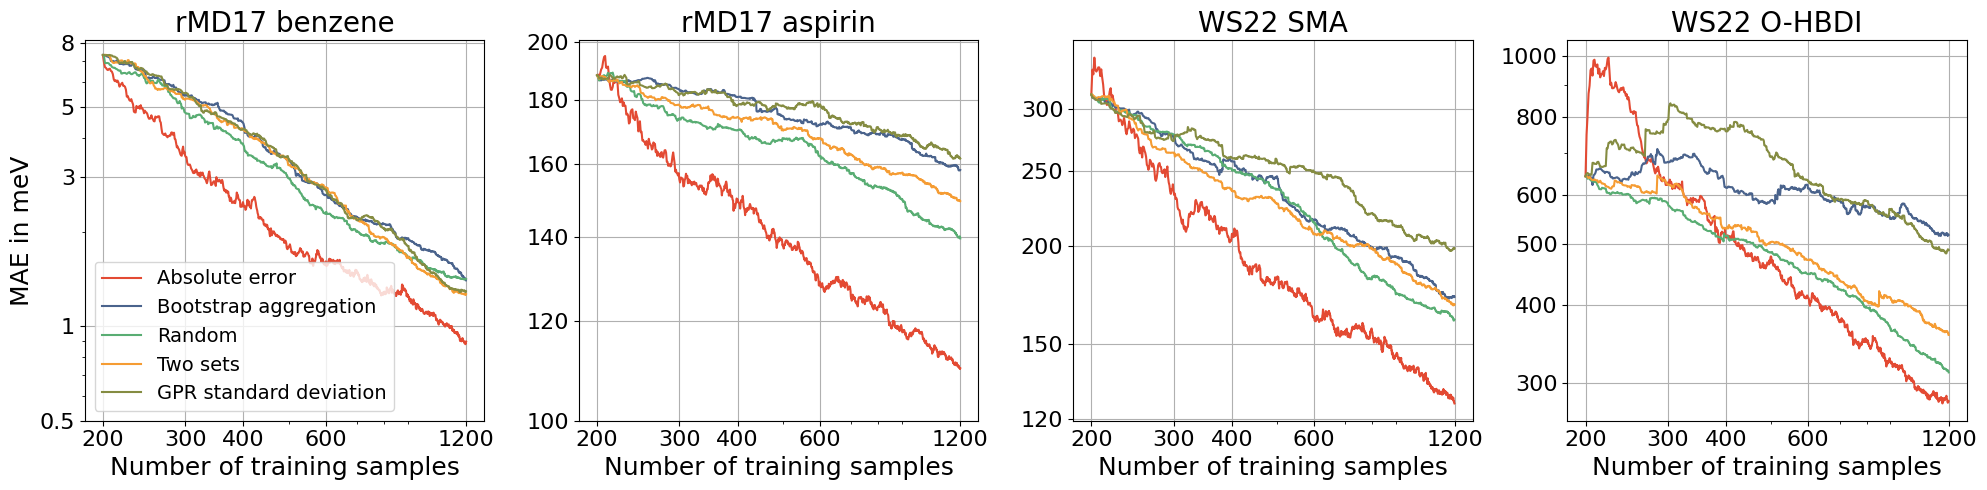

In [9]:
y_ticks = {
    'rMD17 benzene': [0.5, 1, 3, 5, 8],
    'rMD17 aspirin': [100, 120, 140, 160, 180, 200],
    'WS22 SMA': [120, 150, 200, 250, 300],
    'WS22 O-HBDI': [300, 400, 500, 600, 800, 1000],
}

plot_US_LCs(al_dirs_soap, x_ticks_soap, y_ticks, 'MAE in meV', n_init_soap, n_al_soap)
plt.tight_layout()

### Max absolute error

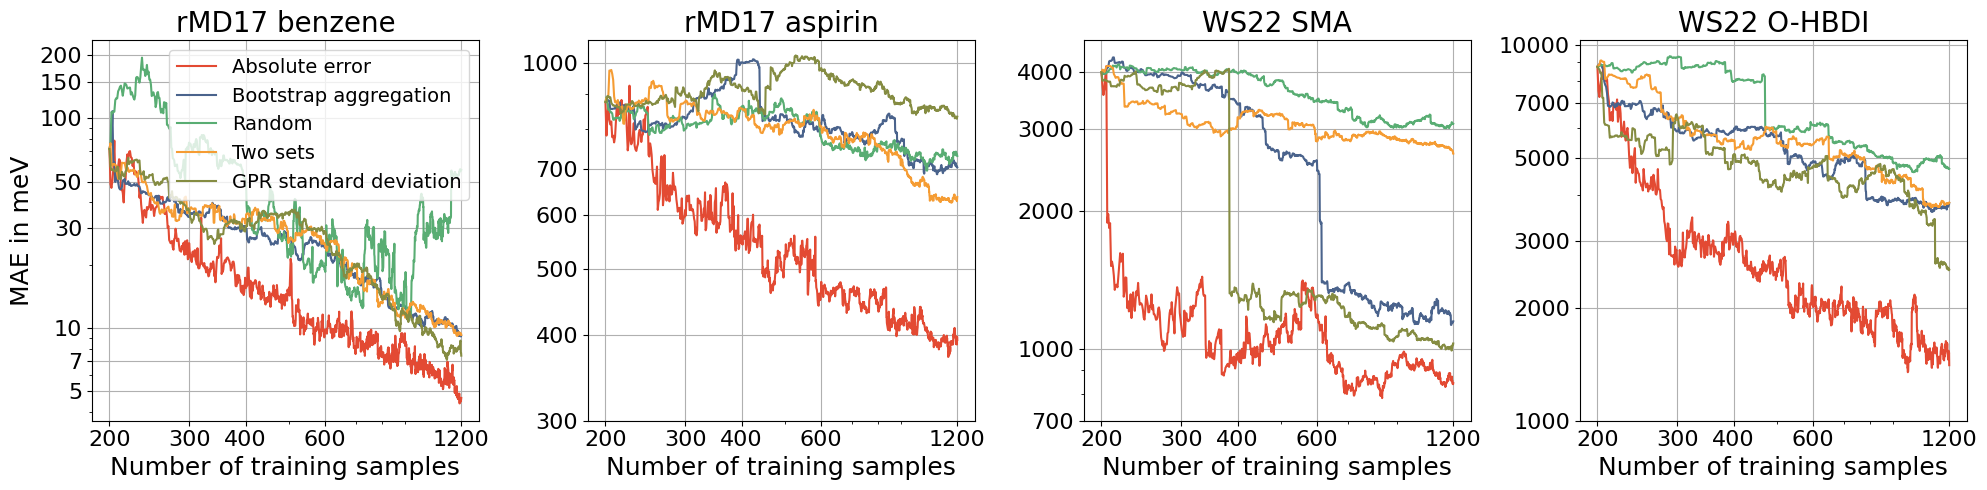

In [10]:
y_ticks = {
    'rMD17 benzene': [5, 7, 10, 30, 50, 100, 150, 200],
    'rMD17 aspirin': [300, 400, 500, 600, 700, 1000],
    'WS22 SMA': [700, 1000, 2000, 3000, 4000],
    'WS22 O-HBDI': [1000, 2000, 3000, 5000, 7000, 10000],
    'Porphyrin': [20, 30, 40, 50, 70, 100, 200, 500],
}

plot_US_LCs(al_dirs_soap, x_ticks_soap, y_ticks, 'Max absolute error in meV', n_init_soap, n_al_soap)
plt.tight_layout()

### Test variance

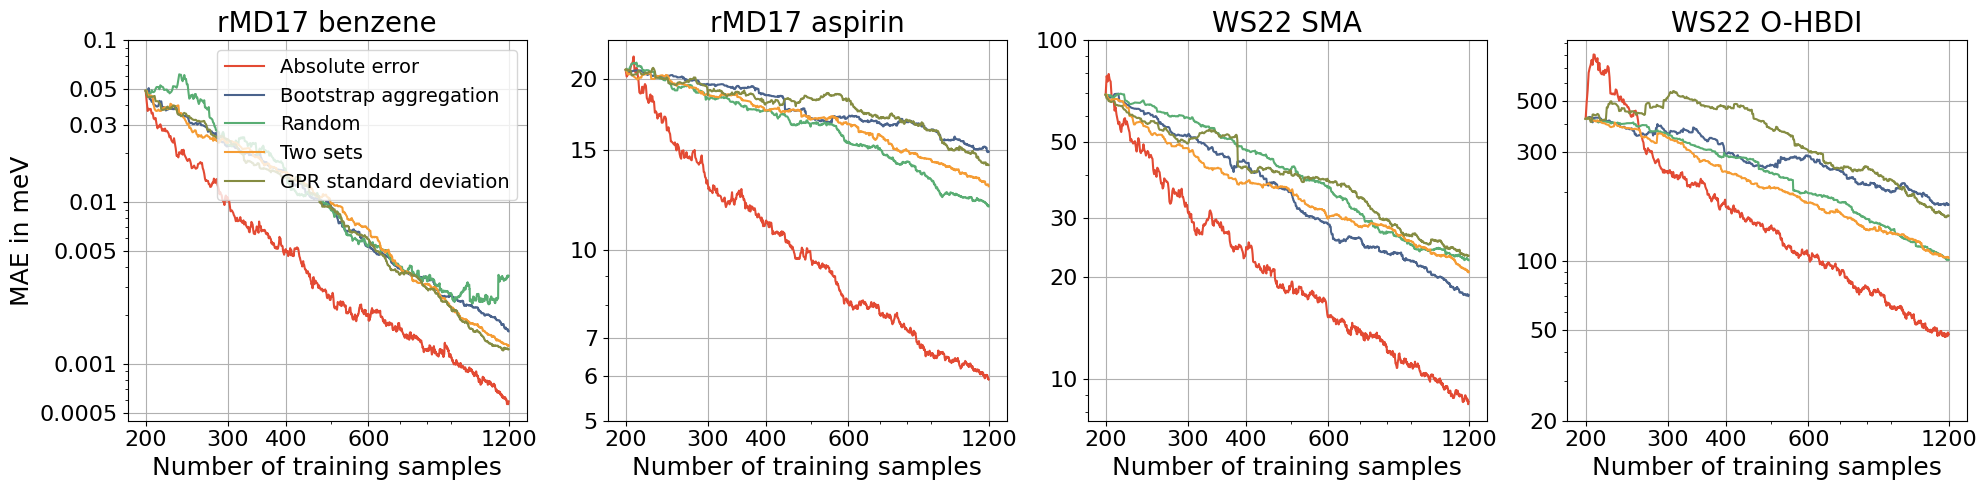

In [11]:
y_ticks = {
    'rMD17 benzene': [0.0005, 0.001, 0.005, 0.01, 0.03, 0.05, 0.1],
    'rMD17 aspirin': [5, 6, 7, 10, 15, 20],
    'WS22 SMA': [10, 20, 30, 50, 100],
    'WS22 O-HBDI': [20, 50, 100, 300, 500],
}

plot_US_LCs(al_dirs_soap, x_ticks_soap, y_ticks, 'Test variance in meV', n_init_soap, n_al_soap)
plt.tight_layout()